In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from scipy import sparse
from sklearn.decomposition import TruncatedSVD, PCA

In [4]:
#pip install umap-learn

  Obtaining dependency information for umap-learn from https://files.pythonhosted.org/packages/43/d2/fcf7192dd1cd8c090b6cfd53fa223c4fb2887a17c47e06bc356d44f40dfb/umap_learn-0.5.11-py3-none-any.whl.metadata
  Using cached umap_learn-0.5.11-py3-none-any.whl.metadata (26 kB)
  Obtaining dependency information for pynndescent>=0.5 from https://files.pythonhosted.org/packages/b2/e6/94145d714402fd5ade00b5661f2d0ab981219e07f7db9bfa16786cdb9c04/pynndescent-0.6.0-py3-none-any.whl.metadata
  Using cached pynndescent-0.6.0-py3-none-any.whl.metadata (6.9 kB)
Using cached umap_learn-0.5.11-py3-none-any.whl (90 kB)
Using cached pynndescent-0.6.0-py3-none-any.whl (73 kB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Attempt UMAP import
try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print(" umap-learn not installed. UMAP comparison will be skipped.")
    print("  Install with: pip install umap-learn")

In [3]:
# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [4]:
# Paths
OUTPUTS_DIR = "outputs/"
FIGURES_DIR = "figures/"

import os
os.makedirs(FIGURES_DIR,exist_ok=True)

## 1 - Load Upstream Data

In [5]:
def load_pkl(filename):
    """Load a pkl file from outputs/. Returns the raw object. """
    path=os.path.join(OUTPUTS_DIR,filename)
    with open(path,"rb")as f:
        obj=pickle.load(f)
    return obj

#---TF-IDF---
tfidf_uni_data=load_pkl("tfidf_unigram_matrix.pkl")
tfidf_bi_data=load_pkl("tfidf_bigram_matrix.pkl")

#Extract components from dict structure
#tfidf_.pkl format: {"matrix":csr_matrix, 'vectorizer':...,"index":...,"period":...,"era":...}
tfidf_uni_matrix=tfidf_uni_data["matrix"]
tfidf_bi_matrix=tfidf_bi_data["matrix"]
period_labels=tfidf_uni_data['period']
era_labels=tfidf_uni_data['era']

print(f"TF-IDF Unigram:{tfidf_uni_matrix.shape}(sparse,nnz={tfidf_uni_matrix.nnz})")
print(f"TF-IDF Bigram:{tfidf_bi_matrix.shape}(sparse,nnz={tfidf_bi_matrix.nnz})")
print(f"Petiod labels:{np.unique(period_labels)}")
print(f"Era labels:{np.unique(era_labels)}")

TF-IDF Unigram:(3222, 7993)(sparse,nnz=211286)
TF-IDF Bigram:(3222, 10000)(sparse,nnz=72289)
Petiod labels:['1991-1995' '1996-2000' '2001-2005' '2006-2010' '2011-2015' '2016-2021']
Era labels:['Deep Learning' 'Machine Learning' 'Statistical Methods'
 'Transformer & Pre-training']


In [ ]:
#---SBERT & LDA---
"""
sbert_data=load_pkl("sbert_matrix.pkl")
lda_data=load_pkl("lda_matrix.pkl")

"""

## 2 - Dimensionality Reduction

## *Methodology note*
## TF-IDF matrices are extremely sparse (>97% zeros). Standard PCA centres the data by subtracting the mean, which destroys sparsity and causes memory issues. We therefore use TruncatedSVD, which is mathematically equivalent to PCA on centred data but operates directly on the sparse matrix.
## For dense matrices (SBERT, LDA), we use standard PCA with explicit centring.

In [7]:
N_COMPONENTS=2 #2D trajectories

def reduce_sparse(matrix, n_components=N_COMPONENTS, random_state=RANDOM_STATE):
    """TruncatedSVD for sparse matrices.Returns (coords_2d, explained_var_ratio)"""
    svd=TruncatedSVD(n_components=n_components,random_state=random_state)
    coords=svd.fit_transform(matrix)
    return coords,svd.explained_variance_ratio_

def reduce_dense(marix, n_components=N_COMPONENTS, random_state=RANDOM_STATE):
    """Standard PCA for dense matrices. Returns (corrds_2d,explained_var_ratio)"""
    pca=PCA(n_components=n_components, random_state=random_state)
    coords=pca.fit_transform(matrix)
    return coords, pca.explained_variance_ratio_

#Run reduction
coords_uni,evr_uni=reduce_sparse(tfidf_uni_matrix)
coords_bi,evr_bi=reduce_sparse(tfidf_bi_matrix)

print(f"TF-IDF Unigram - Explained variance: PC1={evr_uni[0]:.4f}, PC2={evr_uni[1]:.4f},total={evr_uni.sum():.4f}")
print(f"TF-IDF Bigram - Explained variance: PC1={evr_bi[0]:.4f}, PC2={evr_bi[1]:.4f}, total={evr_bi.sum():.4f}")

'''
coords_sbert,evr_sbert=reduce_dense(sbert_matrix)
coords_lda,evr_lda=reduce_dense(ida_matrix)

print(f"SBERT - Explained variance: PC1={evr_sbert[0]:.4f}, PC2={evr_sbert[1]:.4f,total={evr_sbert.sum():.4f}")
print(f"LDA - Explained variance:PC1={evr_lda[0]:.4f}, PC2={evr_lda[1]:.4f, total={evr_lda.sum():.4f}"})'''

TF-IDF Unigram - Explained variance: PC1=0.0023, PC2=0.0052,total=0.0076
TF-IDF Bigram - Explained variance: PC1=0.0014, PC2=0.0030, total=0.0045


'\ncoords_sbert,evr_sbert=reduce_dense(sbert_matrix)\ncoords_lda,evr_lda=reduce_dense(ida_matrix)\n\nprint(f"SBERT - Explained variance: PC1={evr_sbert[0]:.4f}, PC2={evr_sbert[1]:.4f,total={evr_sbert.sum():.4f}")\nprint(f"LDA - Explained variance:PC1={evr_lda[0]:.4f}, PC2={evr_lda[1]:.4f, total={evr_lda.sum():.4f}"})'

## 3 - Compute Per-Period Centroids

In [8]:
#Sorted period order for trajectory lines
PERIOD_ORDER=sorted(np.unique(period_labels))
print(f"Period order for trajectory:{PERIOD_ORDER}")

def compute_centroids(coords_2d, labels, period_order=PERIOD_ORDER):
    """Compute the mean (centroid) of 2D coordinates for each period.
    Returns dict:{period_label:(cx,cy)} and arrays for plotting."""
    centroids={}
    for p in period_order:
        mask=labels==p
        n=mask.sum()
        if n==0:
            continue
        cx,cy=coords_2d[mask].mean(axis=0)
        centroids[p]=(cx,cy,n)
    return centroids

centroids_uni=compute_centroids(coords_uni,period_labels)
centroids_bi=compute_centroids(coords_bi,period_labels)

#Print centroid summary
print("\nCentroids - TF-IDF Unigram:")
for p, (cx,cy,n) in centroids_uni.items():
    print(f"{p}: ({cx:+.4f},{cy:+.4f}) n={n}")

print("\nCentroids - TF-IDF Bigram:")
for p,(cx,cy,n) in centroids_bi.items():
    print(f"{p}:({cx:+.4f},{cy:+.4f}) n={n}")

Period order for trajectory:['1991-1995', '1996-2000', '2001-2005', '2006-2010', '2011-2015', '2016-2021']

Centroids - TF-IDF Unigram:
1991-1995: (+0.1144,-0.0018) n=45
1996-2000: (+0.1342,+0.0015) n=56
2001-2005: (+0.1316,-0.0034) n=29
2006-2010: (+0.1060,-0.0172) n=26
2011-2015: (+0.1587,-0.0048) n=199
2016-2021: (+0.1870,-0.0043) n=2867

Centroids - TF-IDF Bigram:
1991-1995:(+0.0304,-0.0018) n=45
1996-2000:(+0.0348,-0.0015) n=56
2001-2005:(+0.0440,-0.0187) n=29
2006-2010:(+0.0330,-0.0054) n=26
2011-2015:(+0.0553,-0.0022) n=199
2016-2021:(+0.0763,+0.0013) n=2867


## 4 - Trajectory Plot  (PCA/SVD)

In [11]:
#Colour palette: one colour per period, consistent across all subplots
PERIOD_COLOURS={
    '1991-1995':'#2E86AB',
    '1996-2000':'#A23B72',
    '2001-2005':'#F18F01',
    '2006-2010':'#C73E1D',
    '2011-2015':'#3B1F2B',
    '2016-2021':'#44AF69',
}

def plot_trajectory(ax,coords_2d,labels,centroids,title,evr,show_scatter=True,arrow_scale=1.0):
    
    periods_in_order=[p for p in PERIOD_ORDER if p in centroids]
    
    #Scatter points
    if show_scatter:
        for p in periods_in_order:
            mask=labels==p
            ax.scatter(coords_2d[mask,0],coords_2d[mask,1],c=PERIOD_COLOURS[p],alpha=0.15,s=8,edgecolors='none',rasterized=True)
    
    #Centroid markers
    for p in periods_in_order:
        cx,cy,n=centroids[p]
        ax.scatter(cx,cy,c=PERIOD_COLOURS[p],s=120,edgecolors='white',linewidths=1.5,zorder=5)
        #Label with period
        ax.annotate(p,(cx,cy),fontsize=7,fontweight='bold',textcoords='offset points',xytext=(8,6),color=PERIOD_COLOURS[p],path_effects=[pe.withStroke(linewidth=2.5,foreground='white')])
        
    #trajectory arrows between consecutive centroids
    for i in range(len(periods_in_order)-1):
        p1,p2=periods_in_order[i],periods_in_order[i+1]
        x1,y1,_=centroids[p1]
        x2,y2,_=centroids[p2]
        ax.annotate('',xy=(x2,y2),xytext=(x1,y1),arrowprops=dict(arrowstyle='->',color='#333333',lw=1.8,connectionstyle='arc3,rad=0.1'))
        
    #Axis labels with explained variance
    ax.set_xlabel(f'PC1 ({evr[0]:.1%}var)',fontsize=9)
    ax.set_ylabel(f'PC2 ({evr[1]:.1%}var)',fontsize=9)
    ax.set_title(title,fontsize=11,fontweight='bold',pad=10)
    ax.tick_params(labelsize=8)
    ax.grid(True,alpha=0.2)

### Main figure

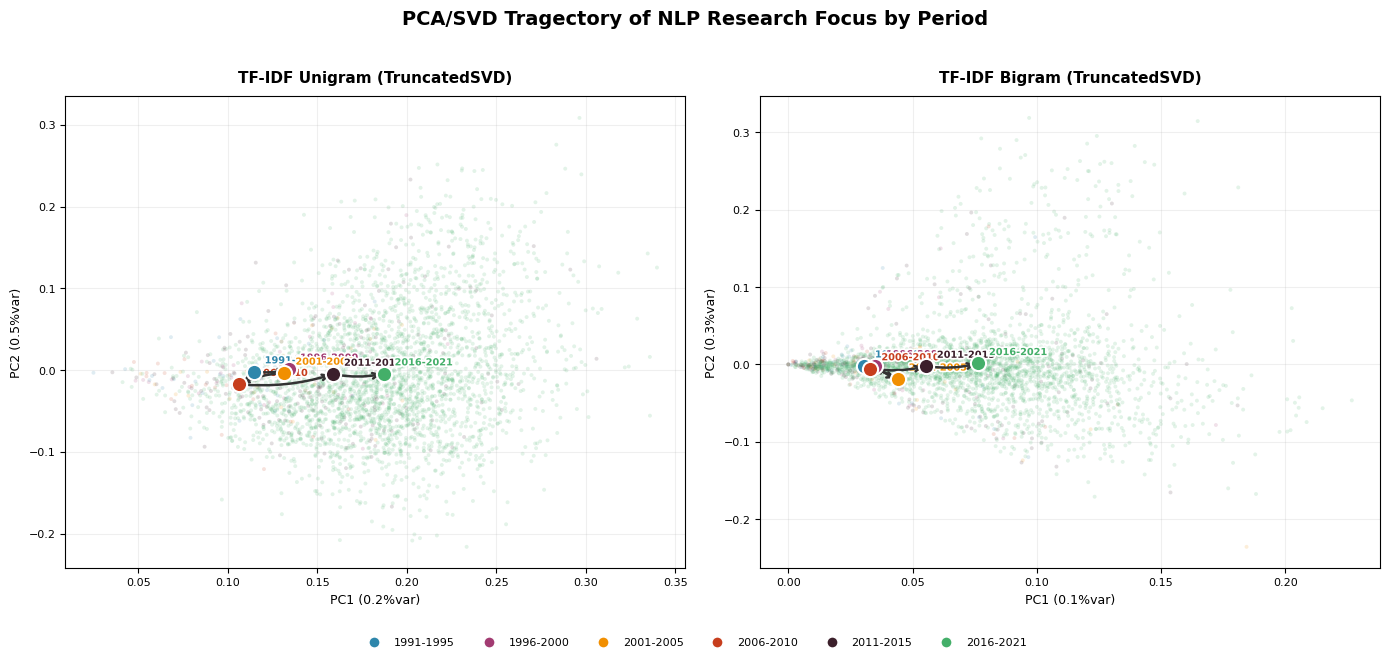

PCA trajectory plots saved to figures/


In [12]:
#Now TF-IDF only
fig,axes=plt.subplots(1,2,figsize=(14,6))
fig.suptitle('PCA/SVD Tragectory of NLP Research Focus by Period',fontsize=14, fontweight='bold',y=1.02)
plot_trajectory(axes[0],coords_uni,period_labels,centroids_uni,'TF-IDF Unigram (TruncatedSVD)',evr_uni)
plot_trajectory(axes[1],coords_bi,period_labels,centroids_bi,'TF-IDF Bigram (TruncatedSVD)', evr_bi)

#Shared legend
legend_handles=[Line2D([0],[0],marker='o',color='w',markerfacecolor=c,markersize=8,label=p) for p,c in PERIOD_COLOURS.items()]
fig.legend(handles=legend_handles,loc='lower center',ncol=6,fontsize=8,frameon=False,bbox_to_anchor=(0.5,-0.06))

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR,'pca_trajectory_tfidf_unigram.png'),dpi=200,bbox_inches='tight')
fig.savefig(os.path.join(FIGURES_DIR,'pca_trajectory_tfidf_bigram.png'),dpi=200,bbox_inches='tight')

plt.show()
print("PCA trajectory plots saved to figures/")